# Cybersecurity Statistics Project
RT-IoT2022 / UCI

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
DATA_URL = 'https://archive.ics.uci.edu/static/public/942/data.csv'
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'rt_iot2022.csv'
PLOTS_DIR = PROJECT_ROOT / 'outputs' / 'plots'
TABLES_DIR = PROJECT_ROOT / 'outputs' / 'tables'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

NORMAL_LABELS = {'Thing_Speak', 'MQTT_Publish', 'Wipro_bulb'}
RANDOM_STATE = 42

## 1. Download / Load / Filter

In [2]:
if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH)
df['traffic_class'] = np.where(df['Attack_type'].isin(NORMAL_LABELS), 'Normal', 'Attack')
df['is_attack'] = (df['traffic_class'] == 'Attack').astype(int)

df.head()

,id,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type,traffic_class,is_attack
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,761.985779,29729182.96,32011597.87,4001449.734,10403073.63,4438.877106,1511693.954,2.026391e+06,506597.757339,680406.147100,761.985779,29729182.96,32011597.87,2.462431e+06,8.199747e+06,3.373777,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2282414.913,2282414.913,2282414.913,2282414.913,0.0,29729182.96,29729182.96,29729182.96,29729182.96,0.0,64240,26847,502,MQTT_Publish,Normal,0
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,247.001648,29855277.06,31883584.02,3985448.003,10463455.56,4214.048386,1576435.804,1.876261e+06,469065.249000,741351.686200,247.001648,29855277.06,31883584.02,2.452583e+06,8.242459e+06,3.387323,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2028306.961,2028306.961,2028306.961,2028306.961,0.0,29855277.06,29855277.06,29855277.06,29855277.06,0.0,64240,26847,502,MQTT_Publish,Normal,0
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,74,8.222222,12.852799,0,21,30,6.0,8.689074,0,33,104,7.428571,11.229866,283.956528,29842149.02,32124053.00,4015506.625,10442377.92,2456.903458,1476048.946,2.013770e+06,503442.466300,660344.360027,283.956528,29842149.02,32124053.00,2.471081e+06,8.230593e+06,3.237450,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2281903.982,2281903.982,2281903.982,2281903.982,0.0,29842149.02,29842149.02,29842149.02,29842149.02,0.0,64240,26847,502,MQTT_Publish,Normal,0
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,74,8.222222,12.852799,0,21,30,6.0,8.689074,0,33,104,7.428571,11.229866,288.963318,29913774.97,31961063.15,3995132.893,10482528.22,3933.906555,1551892.042,1.883784e+06,470946.013927,724569.317900,288.963318,29913774.97,31961063.15,2.458543e+06,8.257786e+06,3.253959,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2047288.179,2047288.179,2047288.179,2047288.179,0.0,29913774.97,29913774.97,29913774.97,29913774.97,0.0,64240,26847,502,MQTT_Publish,Normal,0
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0,33,76,8.444444,13.115936,0,23,32,6.4,9.555103,0,33,108,7.714286,11.618477,387.907028,29814704.90,31902361.87,3987795.234,10447019.10,3005.02

In [3]:
basic_info = pd.DataFrame({
    'metric': [
        'rows', 'columns_after_processing', 'original_columns',
        'numeric_columns', 'categorical_columns', 'missing_values_total'
    ],
    'value': [
        df.shape[0], df.shape[1], df.shape[1] - 2,
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(exclude=np.number).shape[1],
        int(df.isna().sum().sum())
    ]
})

dtype_info = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis('dtype')
    .reset_index(name='count')
)

class_info = (
    df['traffic_class']
    .value_counts()
    .rename_axis('traffic_class')
    .reset_index(name='count')
)
class_info['share'] = class_info['count'] / len(df)

display(basic_info)
display(dtype_info)
display(class_info)

,metric,value
0,rows,123117
1,columns_after_processing,87
2,original_columns,85
3,numeric_columns,83
4,categorical_columns,4
5,missing_values_total,0


,dtype,count
0,float64,47
1,int64,36
2,str,4


,traffic_class,count,share
0,Attack,110610,0.898414
1,Normal,12507,0.101586


In [4]:
feature_description = pd.DataFrame([
    ['flow_duration', 'network flow duration'],
    ['flow_pkts_per_sec', 'packets per second'],
    ['payload_bytes_per_second', 'payload bytes per second'],
    ['fwd_init_window_size', 'initial TCP window size, forward direction'],
    ['flow_iat.avg', 'average inter-arrival time between packets'],
    ['flow_iat.max', 'maximum inter-arrival time between packets'],
    ['fwd_pkts_payload.avg', 'average forward packet payload'],
    ['bwd_init_window_size', 'initial TCP window size, backward direction'],
], columns=['feature', 'meaning'])

feature_description

,feature,meaning
0,flow_duration,network flow duration
1,flow_pkts_per_sec,packets per second
2,payload_bytes_per_second,payload bytes per second
3,fwd_init_window_size,"initial TCP window size, forward direction"
4,flow_iat.avg,average inter-arrival time between packets
5,flow_iat.max,maximum inter-arrival time between packets
6,fwd_pkts_payload.avg,average forward packet payload
7,bwd_init_window_size,"initial TCP window size, backward direction"


## 2. Descriptive Statistics

In [5]:
analysis_features = [
    'flow_duration',
    'flow_pkts_per_sec',
    'payload_bytes_per_second',
    'fwd_init_window_size',
    'flow_iat.avg',
    'flow_iat.max',
    'fwd_pkts_payload.avg',
    'bwd_init_window_size',
]

stats_table = []
for feature in analysis_features:
    s = df[feature].astype(float)
    stats_table.append({
        'feature': feature,
        'count': s.count(),
        'mean': s.mean(),
        'mode': s.mode().iloc[0],
        'variance': s.var(ddof=1),
        'std': s.std(ddof=1),
        'min': s.min(),
        'q1': s.quantile(0.25),
        'median_q2': s.quantile(0.50),
        'q3': s.quantile(0.75),
        'max': s.max(),
    })

stats_table = pd.DataFrame(stats_table).round(4)
stats_table.to_csv(TABLES_DIR / 'selected_descriptive_statistics.csv', index=False)
stats_table

,feature,count,mean,mode,variance,std,min,q1,median_q2,q3,max
0,flow_duration,123117,3.809600e+00,0.000000e+00,1.690141e+04,1.300054e+02,0.0,0.0000,0.000000e+00,0.000000e+00,2.172834e+04
1,flow_pkts_per_sec,123117,7.035683e+05,4.934475e+05,5.499163e+11,7.415634e+05,0.0,149.0871,4.934475e+05,1.048576e+06,2.097152e+06
2,payload_bytes_per_second,123117,4.105345e+07,2.960685e+07,2.012156e+15,4.485706e+07,0.0,2580.9811,2.960685e+07,5.592405e+07,1.258291e+08
3,fwd_init_window_size,123117,6.118905e+03,6.400000e+01,3.503004e+08,1.871631e+04,0.0,64.0000,6.400000e+01,6.400000e+01,6.553500e+04
4,flow_iat.avg,123117,1.396545e+05,4.053100e+00,7.652797e+11,8.748026e+05,0.0,0.9537,4.053100e+00,5.006800e+00,7.283576e+07
5,flow_iat.max,123117,1.725999e+06,4.053100e+00,8.556710e+13,9.250249e+06,0.0,0.9537,4.053100e+00,5.006800e+00,3.000000e+08
6,fwd_pkts_payload.avg,123117,1.005238e+02,1.200000e+02,2.125009e+03,4.609780e+01,0.0,120.0000,1.200000e+02,1.200000e+02,1.319365e+03
7,bwd_init_window_size,123117,2.739776e+03,0.000000e+00,1.003773e+08,1.001885e+04,0.0,0.0000,0.000000e+00,0.000000e+00,6.553500e+04


In [6]:
group_stats = (
    df.groupby('traffic_class')[['flow_duration', 'flow_pkts_per_sec', 'payload_bytes_per_second']]
    .agg(['count', 'mean', 'median', 'std', 'var', 'min', 'max'])
    .round(4)
)

group_stats

flow_duration                                                          flow_pkts_per_sec                                                                          \
                      count     mean  median       std          var  min         max             count         mean       median          std           var  min           max   
traffic_class                                                                                                                                                                    
Attack               110610   1.2029  0.0000   29.2218     853.9124  0.0   5341.3923            110610  783116.1723  493447.5294  741489.3200  5.498064e+11  0.0  2.097152e+06   
Normal                12507  26.8628  0.8794  397.7975  158242.8179  0.0  21728.3356             12507      58.9350      15.7717     356.5393  1.271203e+05  0.0  1.667715e+04   

              payload_bytes_per_second                                                                             
                                 count          mean        median           std           var  min           max  
traffic_class                                                                                                      
Attack                          110610  4.569507e+07  2.960685e+07  4.502881e+07  2.027594e+15  0.0  1.258291e+08  
Normal                           12507  3.656204e+03  9.750406e+02  2.761093e+04  7.623637e+08  0.0  1.817810e+06

## 3. Correlation Matrix

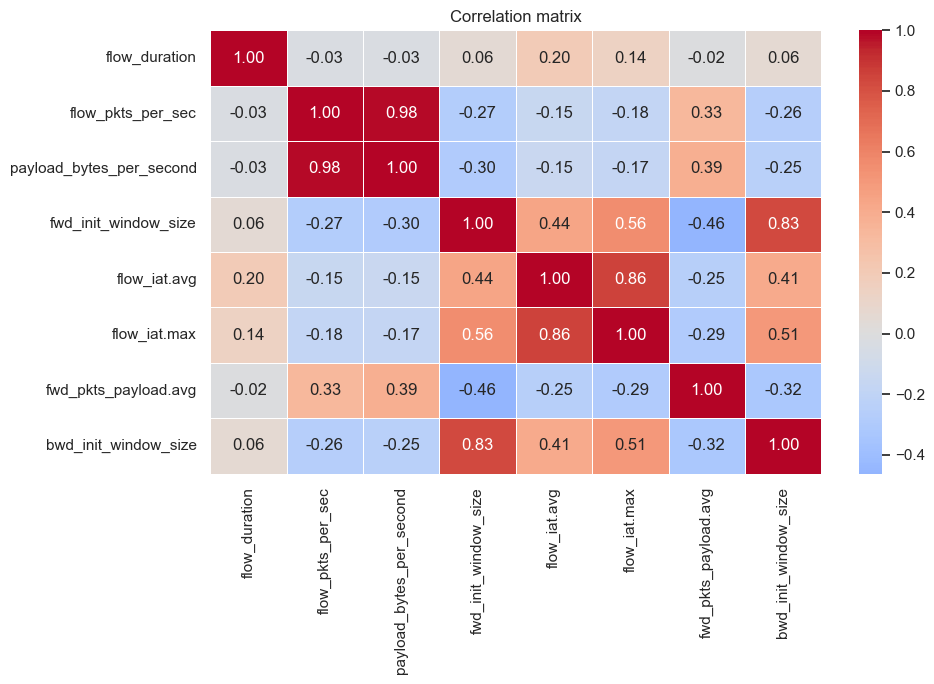

,flow_duration,flow_pkts_per_sec,payload_bytes_per_second,fwd_init_window_size,flow_iat.avg,flow_iat.max,fwd_pkts_payload.avg,bwd_init_window_size
flow_duration,1.000,-0.028,-0.027,0.057,0.198,0.136,-0.016,0.061
flow_pkts_per_sec,-0.028,1.000,0.984,-0.274,-0.151,-0.177,0.332,-0.259
payload_bytes_per_second,-0.027,0.984,1.000,-0.296,-0.146,-0.171,0.386,-0.250
fwd_init_window_size,0.057,-0.274,-0.296,1.000,0.439,0.556,-0.462,0.834
flow_iat.avg,0.198,-0.151,-0.146,0.439,1.000,0.855,-0.253,0.406
flow_iat.max,0.136,-0.177,-0.171,0.556,0.855,1.000,-0.290,0.506
fwd_pkts_payload.avg,-0.016,0.332,0.386,-0.462,-0.253,-0.290,1.000,-0.325
bwd_init_window_size,0.061,-0.259,-0.250,0.834,0.406,0.506,-0.325,1.000


In [7]:
corr = df[analysis_features].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_heatmap.png', dpi=200)
plt.show()

corr.round(3)

## 4. Histograms + Normal Curve
Transform: `log10(x + eps)`

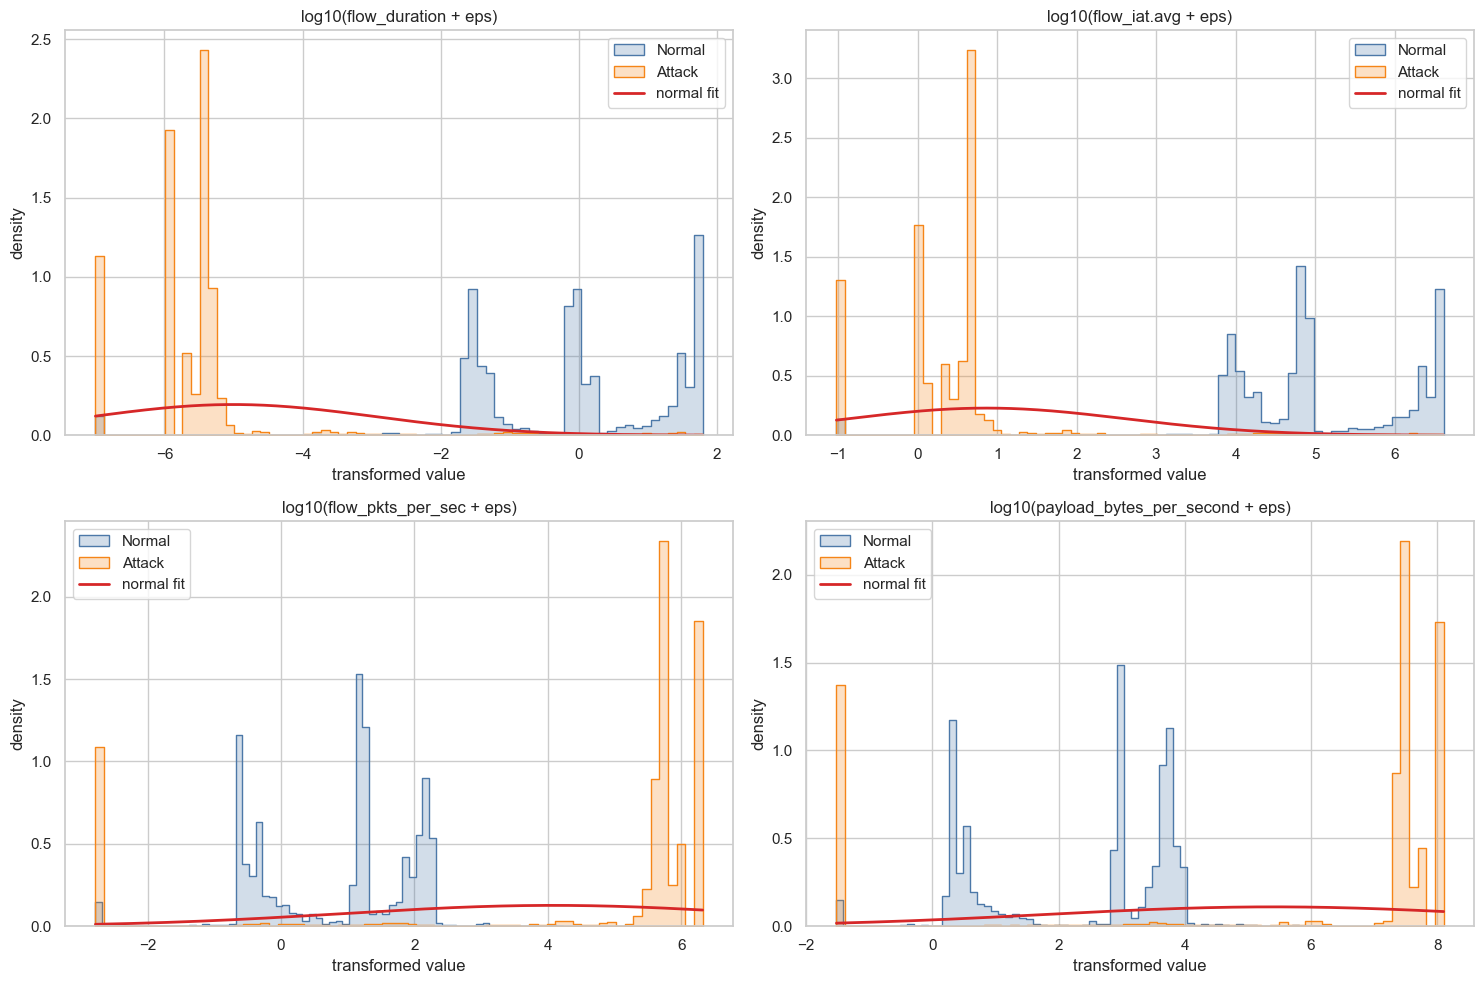

,feature,eps,plotted_rows,transform_min,transform_max,mean_transformed,std_transformed
0,flow_duration,0.000000,49750,-7.000000,1.794421,-5.000477,2.056745
1,flow_iat.avg,0.095367,49750,-1.020600,6.617029,0.869634,1.747726
2,flow_pkts_per_sec,0.001648,50000,-2.783175,6.321630,4.079782,3.150811
3,payload_bytes_per_second,0.030194,50000,-1.520074,8.099781,5.406360,3.618373


In [8]:
hist_features = ['flow_duration', 'flow_iat.avg', 'flow_pkts_per_sec', 'payload_bytes_per_second']
plot_sample = df.sample(n=min(50000, len(df)), random_state=RANDOM_STATE).copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()
colors = {'Normal': '#4C78A8', 'Attack': '#F58518'}

histogram_summary = []
for ax, feature in zip(axes, hist_features):
    x_raw = plot_sample[feature].astype(float)
    positive = x_raw[x_raw > 0]
    eps = positive.min() / 10 if len(positive) else 1e-9
    transformed_col = f'log10_{feature}'
    plot_sample[transformed_col] = np.log10(x_raw + eps)

    lo = plot_sample[transformed_col].quantile(0.005)
    hi = plot_sample[transformed_col].quantile(0.995)
    plot_df = plot_sample[plot_sample[transformed_col].between(lo, hi)].copy()

    for class_name in ['Normal', 'Attack']:
        class_values = plot_df.loc[plot_df['traffic_class'] == class_name, transformed_col]
        sns.histplot(
            class_values,
            bins=70,
            stat='density',
            element='step',
            fill=True,
            alpha=0.25,
            color=colors[class_name],
            label=class_name,
            ax=ax,
        )

    values = plot_df[transformed_col].dropna()
    mu, sigma = norm.fit(values)
    grid = np.linspace(values.min(), values.max(), 300)
    ax.plot(grid, norm.pdf(grid, mu, sigma), color='#D62728', linewidth=2, label='normal fit')
    ax.set_title(f'log10({feature} + eps)')
    ax.set_xlabel('transformed value')
    ax.set_ylabel('density')
    ax.legend()

    histogram_summary.append({
        'feature': feature,
        'eps': eps,
        'plotted_rows': len(plot_df),
        'transform_min': values.min(),
        'transform_max': values.max(),
        'mean_transformed': values.mean(),
        'std_transformed': values.std(ddof=1),
    })

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'histograms_normal_overlay.png', dpi=200)
plt.show()

pd.DataFrame(histogram_summary).round(6)

## 5. Boxplots

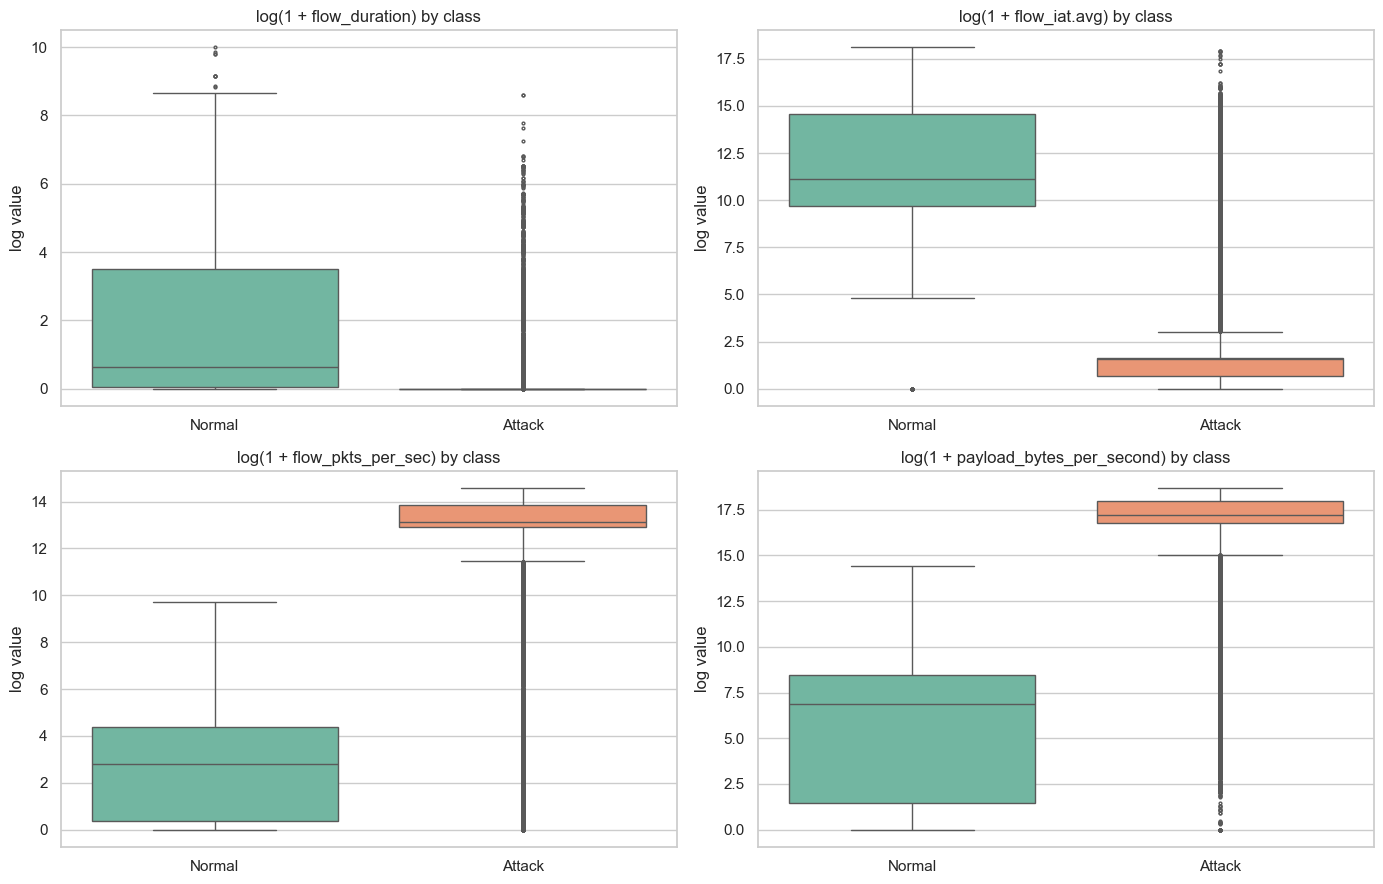

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, feature in zip(axes, hist_features):
    plot_df = df[['traffic_class', feature]].copy()
    plot_df[f'log_{feature}'] = np.log1p(plot_df[feature].astype(float))
    sns.boxplot(
        data=plot_df,
        x='traffic_class',
        y=f'log_{feature}',
        hue='traffic_class',
        palette='Set2',
        showfliers=True,
        fliersize=2,
        linewidth=1,
        ax=ax,
        legend=False,
    )
    ax.set_title(f'log(1 + {feature}) by class')
    ax.set_xlabel('')
    ax.set_ylabel('log value')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'boxplots_iqr_outliers_visible.png', dpi=200)
plt.show()

## 6. IQR Bounds and Outliers

In [11]:
iqr_table = []
all_outliers = []

for feature in analysis_features:
    s = df[feature].astype(float)
    q1 = s.quantile(0.25)
    q2 = s.quantile(0.50)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    in_bounds = s.between(lower, upper, inclusive='both')
    outlier_mask = ~in_bounds

    iqr_table.append({
        'feature': feature,
        'q1': q1,
        'q2_median': q2,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'in_bounds_count': int(in_bounds.sum()),
        'outlier_count': int(outlier_mask.sum()),
        'outlier_share': outlier_mask.mean(),
    })

    feature_outliers = df.loc[outlier_mask, ['traffic_class', 'Attack_type', feature]].copy()
    feature_outliers = feature_outliers.rename(columns={feature: 'value'})
    feature_outliers['feature'] = feature
    all_outliers.append(feature_outliers[['feature', 'value', 'traffic_class', 'Attack_type']])

iqr_table = pd.DataFrame(iqr_table).sort_values('outlier_count', ascending=False).round(6)
all_outliers = pd.concat(all_outliers, ignore_index=True)

iqr_table.to_csv(TABLES_DIR / 'iqr_bounds_selected_features.csv', index=False)
all_outliers.to_csv(TABLES_DIR / 'all_iqr_outliers_selected_features.csv', index=False)

iqr_table

,feature,q1,q2_median,q3,iqr,lower_bound,upper_bound,in_bounds_count,outlier_count,outlier_share
3,fwd_init_window_size,64.000000,6.400000e+01,6.400000e+01,0.000000e+00,6.400000e+01,6.400000e+01,94659,28458,0.231146
6,fwd_pkts_payload.avg,120.000000,1.200000e+02,1.200000e+02,0.000000e+00,1.200000e+02,1.200000e+02,94659,28458,0.231146
4,flow_iat.avg,0.953674,4.053116e+00,5.006790e+00,4.053116e+00,-5.126000e+00,1.108646e+01,103937,19180,0.155787
5,flow_iat.max,0.953674,4.053116e+00,5.006790e+00,4.053116e+00,-5.126000e+00,1.108646e+01,103937,19180,0.155787
0,flow_duration,0.000001,4.000000e-06,5.000000e-06,4.000000e-06,-5.000000e-06,1.100000e-05,103946,19171,0.155714
7,bwd_init_window_size,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,112758,10359,0.084139
2,payload_bytes_per_second,2580.981105,2.960685e+07,5.592405e+07,5.592147e+07,-8.387963e+07,1.398063e+08,123117,0,0.000000
1,flow_pkts_per_sec,149.087077,4.934475e+05,1.048576e+06,1.048427e+06,-1.572491e+06,2.621216e+06,123117,0,0.000000


In [12]:
target_feature = 'flow_duration'
row = iqr_table[iqr_table['feature'] == target_feature].iloc[0]

in_bounds_example = df.loc[
    df[target_feature].between(row['lower_bound'], row['upper_bound'], inclusive='both'),
    ['traffic_class', 'Attack_type', target_feature]
].head(10)

outliers_example = all_outliers[all_outliers['feature'] == target_feature].head(10)

display(pd.DataFrame([row]))
display(in_bounds_example)
display(outliers_example)
print('Total outliers across selected features:', len(all_outliers))

,feature,q1,q2_median,q3,iqr,lower_bound,upper_bound,in_bounds_count,outlier_count,outlier_share
0,flow_duration,0.000001,0.000004,0.000005,0.000004,-0.000005,0.000011,103946,19171,0.155714


,traffic_class,Attack_type,flow_duration
511,Normal,MQTT_Publish,0.0
512,Normal,MQTT_Publish,0.0
513,Normal,MQTT_Publish,0.0
514,Normal,MQTT_Publish,0.0
515,Normal,MQTT_Publish,0.0
1253,Normal,MQTT_Publish,0.0
3141,Normal,MQTT_Publish,0.0
4204,Normal,Thing_Speak,0.0
4324,Normal,Thing_Speak,0.0
4446,Normal,Thing_Speak,0.0


,feature,value,traffic_class,Attack_type
0,flow_duration,32.011598,Normal,MQTT_Publish
1,flow_duration,31.883584,Normal,MQTT_Publish
2,flow_duration,32.124053,Normal,MQTT_Publish
3,flow_duration,31.961063,Normal,MQTT_Publish
4,flow_duration,31.902362,Normal,MQTT_Publish
5,flow_duration,31.869686,Normal,MQTT_Publish
6,flow_duration,32.094711,Normal,MQTT_Publish
7,flow_duration,32.104011,Normal,MQTT_Publish
8,flow_duration,32.026967,Normal,MQTT_Publish
9,flow_duration,32.048637,Normal,MQTT_Publish


Total outliers across selected features: 124806


## 7. Scatter Plot

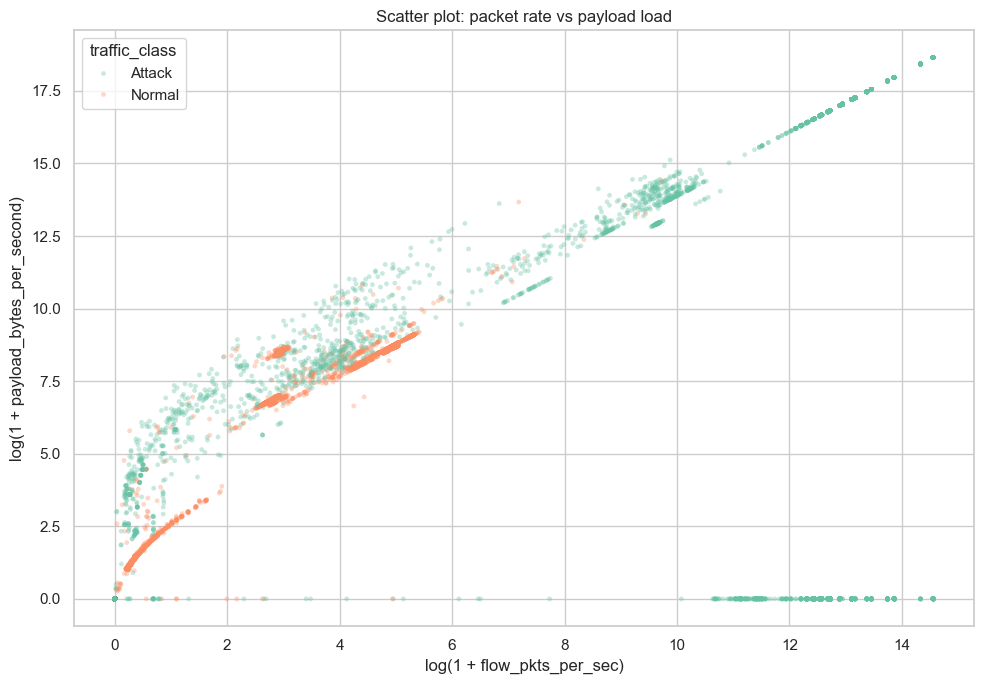

In [10]:
scatter_sample = df.sample(n=min(30000, len(df)), random_state=RANDOM_STATE).copy()
scatter_sample['log_flow_pkts_per_sec'] = np.log1p(scatter_sample['flow_pkts_per_sec'])
scatter_sample['log_payload_bytes_per_second'] = np.log1p(scatter_sample['payload_bytes_per_second'])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scatter_sample,
    x='log_flow_pkts_per_sec',
    y='log_payload_bytes_per_second',
    hue='traffic_class',
    alpha=0.35,
    s=12,
    linewidth=0,
    palette='Set2',
)
plt.title('Scatter plot: packet rate vs payload load')
plt.xlabel('log(1 + flow_pkts_per_sec)')
plt.ylabel('log(1 + payload_bytes_per_second)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'scatter_log_payload_packet_rate.png', dpi=200)
plt.show()

## 8. Shapiro-Wilk Normality Test

In [13]:
normality_rows = []
normal_df = df[df['traffic_class'] == 'Normal']

for feature in hist_features:
    sample = normal_df[feature].astype(float).sample(
        n=min(5000, len(normal_df)),
        random_state=RANDOM_STATE,
    )
    shapiro_stat, shapiro_p = stats.shapiro(sample)
    normality_rows.append({
        'feature': feature,
        'sample_size': len(sample),
        'shapiro_stat': shapiro_stat,
        'shapiro_p': shapiro_p,
        'normal_alpha_0_05': shapiro_p >= 0.05,
    })

normality_tests = pd.DataFrame(normality_rows).round(6)
normality_tests.to_csv(TABLES_DIR / 'normality_tests.csv', index=False)
normality_tests

,feature,sample_size,shapiro_stat,shapiro_p,normal_alpha_0_05
0,flow_duration,5000,0.022555,0.0,False
1,flow_iat.avg,5000,0.474007,0.0,False
2,flow_pkts_per_sec,5000,0.069163,0.0,False
3,payload_bytes_per_second,5000,0.047548,0.0,False


## 9. Levene Variance Test + Welch t-test

In [14]:
test_feature = 'payload_bytes_per_second'
attack_values = df.loc[df['traffic_class'] == 'Attack', test_feature].astype(float)
normal_values = df.loc[df['traffic_class'] == 'Normal', test_feature].astype(float)

# Levene test for equality of variances
levene_stat, levene_p = stats.levene(attack_values, normal_values, center='median')

# Welch t-test for equality of means when variances are not assumed equal
welch_stat, welch_p = stats.ttest_ind(attack_values, normal_values, equal_var=False)

hypothesis_results = pd.DataFrame([
    ['Levene test', 'equal variances', levene_stat, levene_p, 'reject H0' if levene_p < 0.05 else 'fail to reject H0'],
    ['Welch t-test', 'equal means', welch_stat, welch_p, 'reject H0' if welch_p < 0.05 else 'fail to reject H0'],
], columns=['test', 'H0', 'statistic', 'p_value', 'decision_alpha_0_05'])

hypothesis_results.to_csv(TABLES_DIR / 'variance_and_mean_tests.csv', index=False)
hypothesis_results

,test,H0,statistic,p_value,decision_alpha_0_05
0,Levene test,equal variances,10186.714599,0.0,reject H0
1,Welch t-test,equal means,337.474225,0.0,reject H0


In [15]:
mean_table = pd.DataFrame({
    'group': ['Attack', 'Normal'],
    'mean': [attack_values.mean(), normal_values.mean()],
    'variance': [attack_values.var(ddof=1), normal_values.var(ddof=1)],
    'count': [len(attack_values), len(normal_values)],
})
mean_table.round(4)

,group,mean,variance,count
0,Attack,4.569507e+07,2.027594e+15,110610
1,Normal,3.656204e+03,7.623637e+08,12507


## 10. Linear Regression

In [16]:
x_feature = 'flow_pkts_per_sec'
y_feature = 'payload_bytes_per_second'

regression_df = df[[x_feature, y_feature]].replace([np.inf, -np.inf], np.nan).dropna().astype(float)
result = stats.linregress(regression_df[x_feature], regression_df[y_feature])
regression_df['prediction'] = result.intercept + result.slope * regression_df[x_feature]

r2 = result.rvalue ** 2
mse = np.mean((regression_df[y_feature] - regression_df['prediction']) ** 2)

regression_summary = pd.DataFrame([{
    'x_feature': x_feature,
    'y_feature': y_feature,
    'slope': result.slope,
    'intercept': result.intercept,
    'r_value': result.rvalue,
    'coefficient_of_determination_R2': r2,
    'MSE': mse,
    'p_value': result.pvalue,
}]).round(6)

regression_summary.to_csv(TABLES_DIR / 'regression_summary_final.csv', index=False)
regression_summary

,x_feature,y_feature,slope,intercept,r_value,coefficient_of_determination_R2,MSE,p_value
0,flow_pkts_per_sec,payload_bytes_per_second,59.539518,-836665.188817,0.984289,0.968826,6.272714e+13,0.0


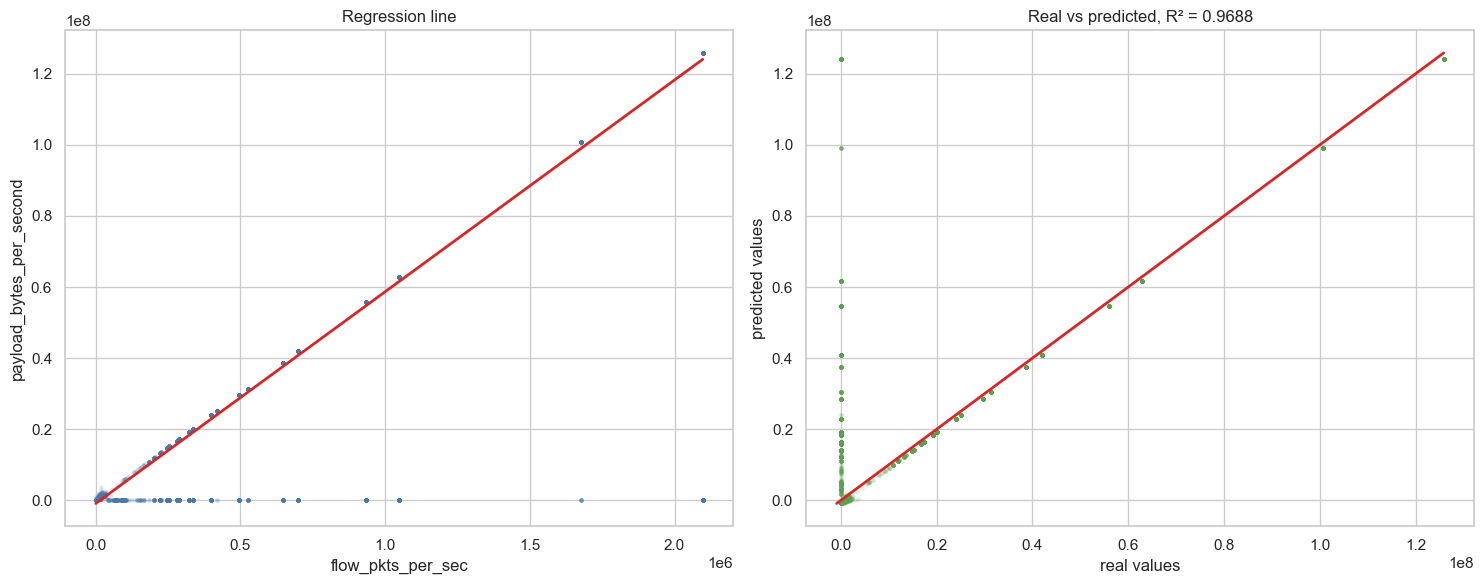

In [17]:
reg_sample = regression_df.sample(n=min(30000, len(regression_df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=reg_sample,
    x=x_feature,
    y=y_feature,
    alpha=0.18,
    s=10,
    linewidth=0,
    ax=axes[0],
    color='#4C78A8',
)
x_grid = np.linspace(reg_sample[x_feature].min(), reg_sample[x_feature].max(), 200)
y_grid = result.intercept + result.slope * x_grid
axes[0].plot(x_grid, y_grid, color='#D62728', linewidth=2)
axes[0].set_title('Regression line')
axes[0].set_xlabel(x_feature)
axes[0].set_ylabel(y_feature)

sns.scatterplot(
    data=reg_sample,
    x=y_feature,
    y='prediction',
    alpha=0.18,
    s=10,
    linewidth=0,
    ax=axes[1],
    color='#59A14F',
)
min_val = min(reg_sample[y_feature].min(), reg_sample['prediction'].min())
max_val = max(reg_sample[y_feature].max(), reg_sample['prediction'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='#D62728', linewidth=2)
axes[1].set_title(f'Real vs predicted, R² = {r2:.4f}')
axes[1].set_xlabel('real values')
axes[1].set_ylabel('predicted values')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'linear_regression_real_predicted.png', dpi=200)
plt.show()

## 11. Result
Attack traffic has higher packet rate and higher payload load. Tests show statistically significant differences between `Attack` and `Normal`.